In [1]:
%cd ..

/home/eli/jupyterlab/captcha-numpyro


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-08-03_00-19-30/saved/checkpoint-epoch50.npy", "+experiment=poisson_convsc",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [5]:
metrics

{'loss': np.float32(-2.5551808e+06),
 'log_w': np.float32(2.5551808e+06),
 'nll': np.float32(-79908.36),
 'kl': np.float32(58.959675),
 'log_Z': np.float32(-20962.557),
 'ess': np.float32(0.25)}

In [6]:
for data, target in objects['datamodule'].valid_dataloader():
    metrics, predictions = objects['learner'](data, stage="valid")
    break

/home/eli/jupyterlab/captcha-numpyro/src/inference/tracer.py:132: UserWarning: Found vars in model but not guide: {'obs'}
  check_model_guide_match(model_trace, guide_trace)


/tmp/ipykernel_2274717/2893736054.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2)


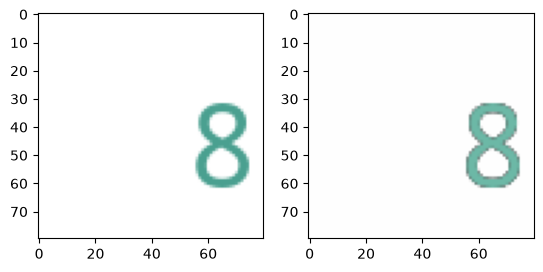

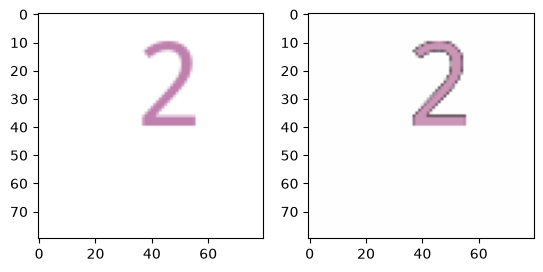

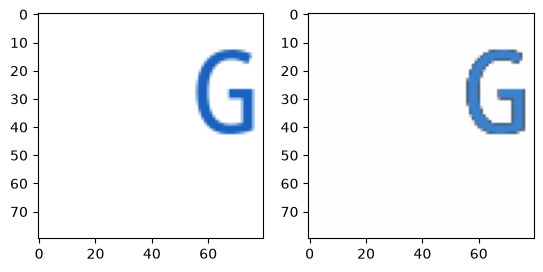

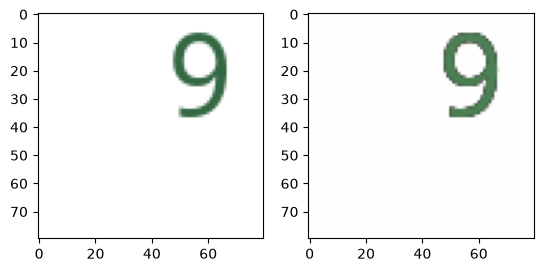

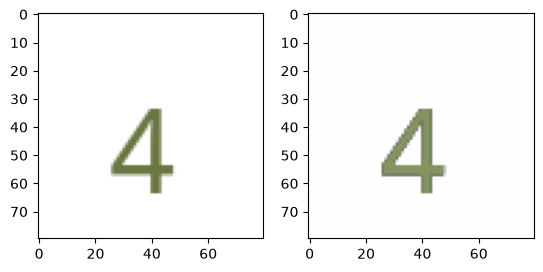

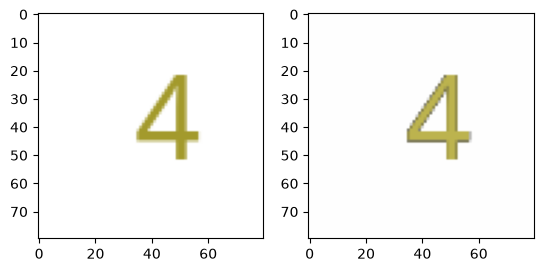

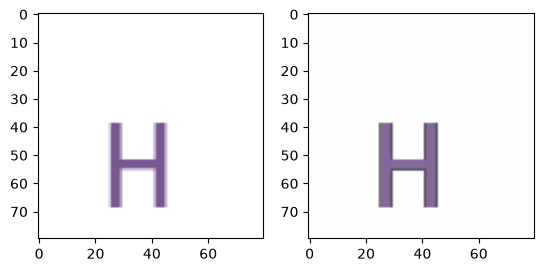

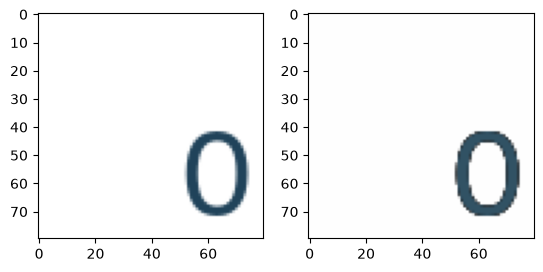

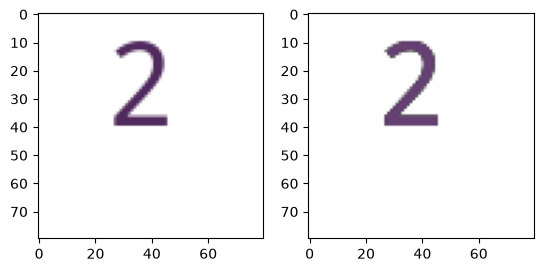

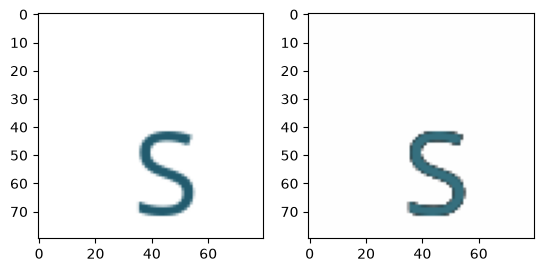

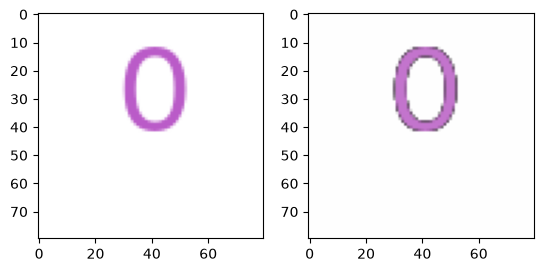

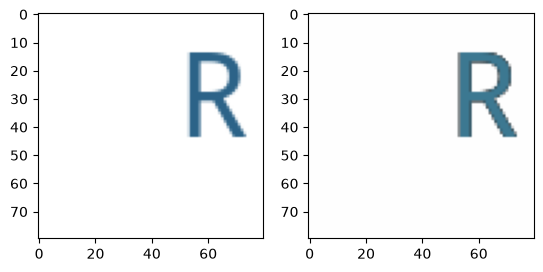

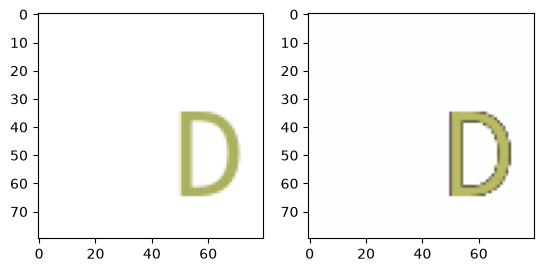

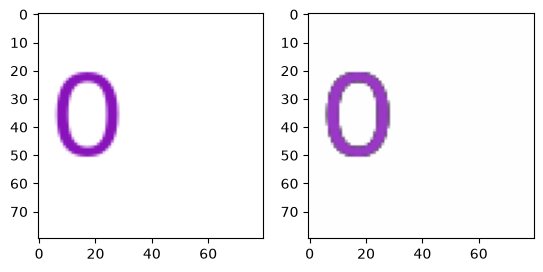

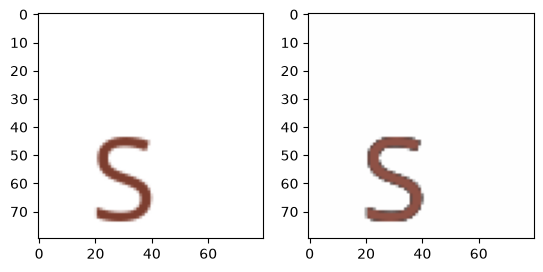

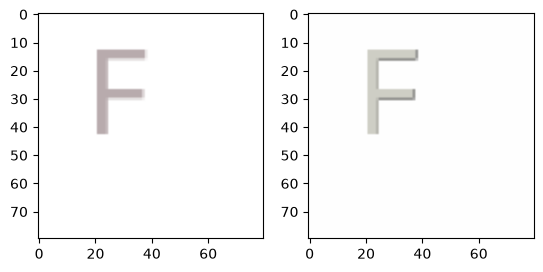

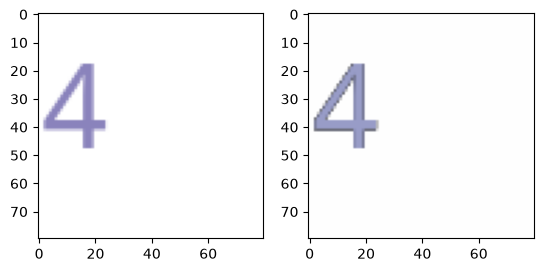

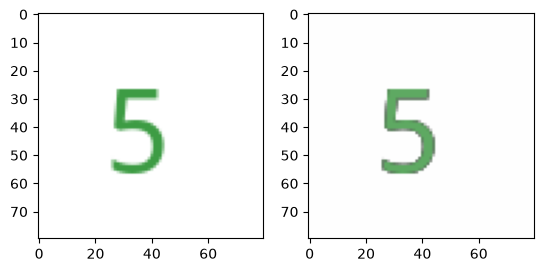

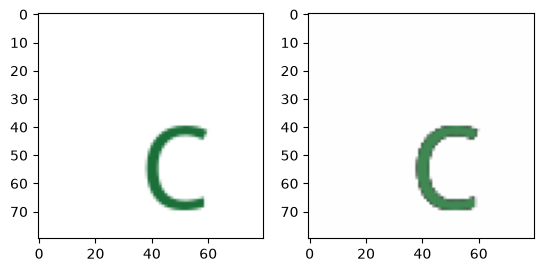

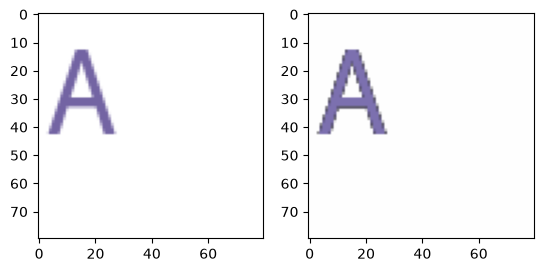

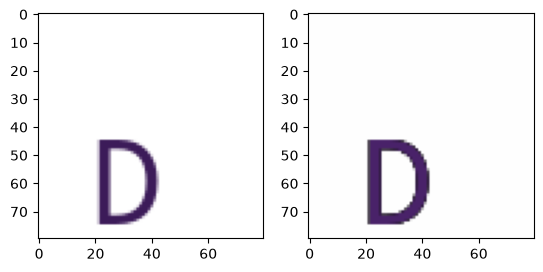

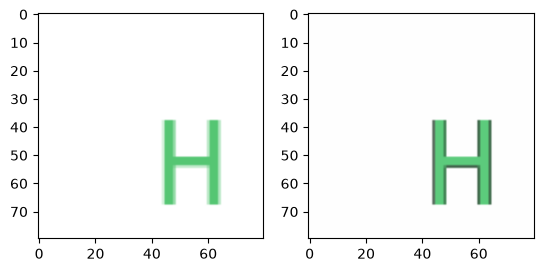

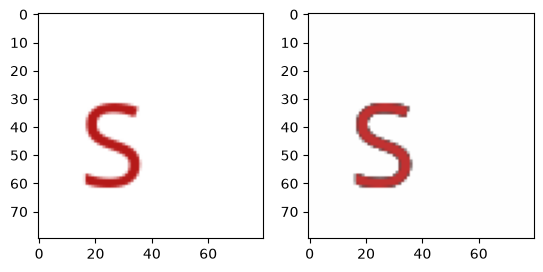

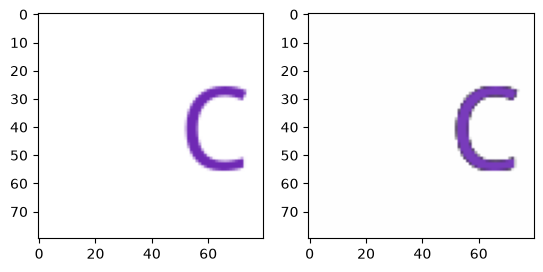

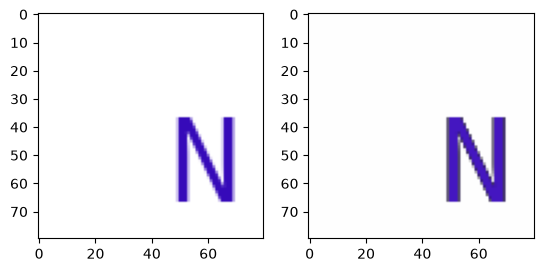

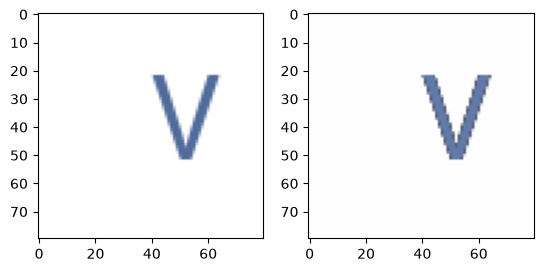

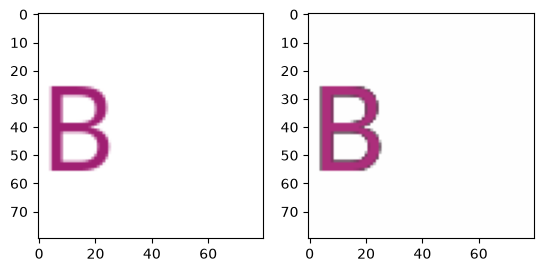

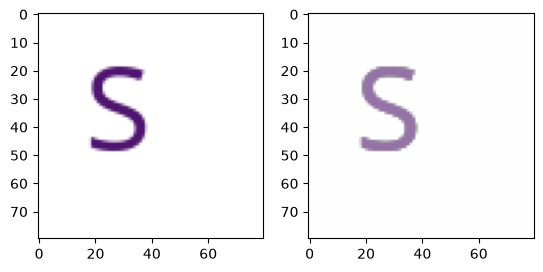

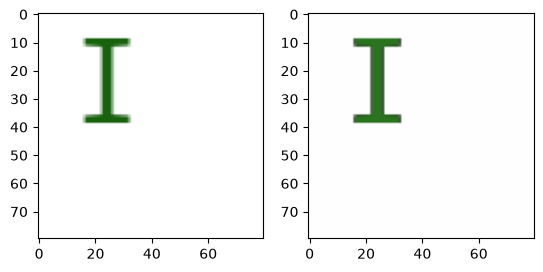

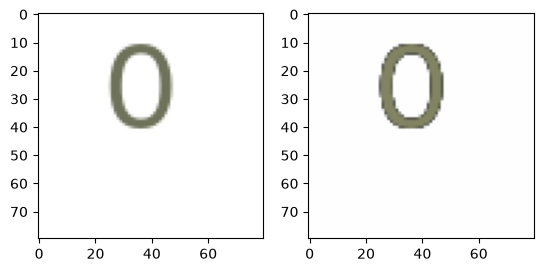

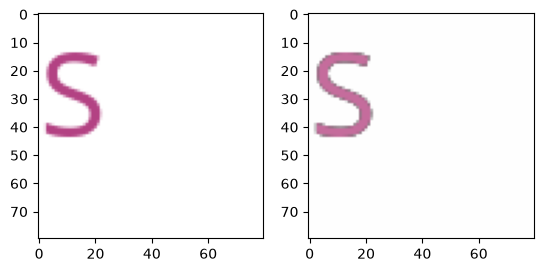

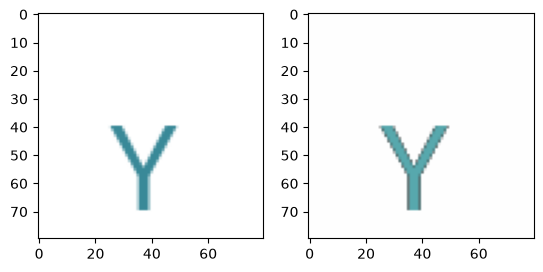

In [7]:
for i in range(data.shape[0]):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(data[i])
    axes[1].imshow(predictions["obs"]["ev"].mean(axis=0)[i])